In [4]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)



Path to dataset files: /Users/a_/.cache/kagglehub/datasets/shauryasrivastava01/liver-patient-dataset/versions/1


In [6]:
path = "Datasets/Teen_Mental_Health_Dataset.csv"
df = pd.read_csv(path)

In [7]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [8]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### Distribuzione della classe depression_label (il target)

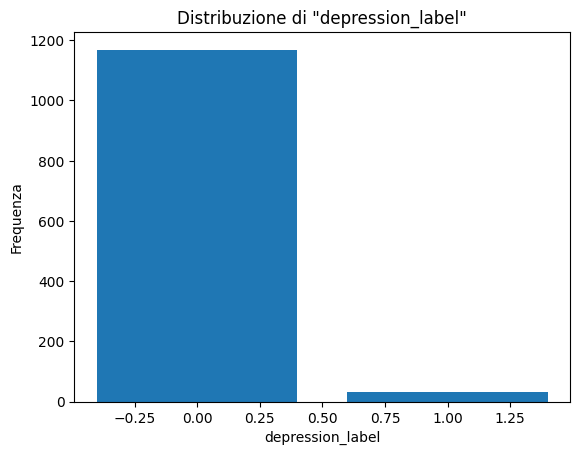

In [9]:
conteggi = df["depression_label"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("depression_label")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "depression_label"')
plt.show()

### Creazione trainining e testing set

In [10]:
feature_names = set(df.columns) - set(["depression_label"])

target_name = "depression_label"

categorical_features = set(["gender", "platform_usage", "social_interaction_level"])
continuos_features = feature_names - set(["gender", "platform_usage", "social_interaction_level"])

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'platform_usage', 'gender', 'social_interaction_level'}
{'academic_performance', 'stress_level', 'physical_activity', 'age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'anxiety_level', 'addiction_level'}


In [11]:
df_encoded = df.copy()

df_encoded["gender"] = df_encoded["gender"].astype("category").cat.codes
df_encoded["platform_usage"] = df_encoded["platform_usage"].astype("category").cat.codes
df_encoded["social_interaction_level"] = df_encoded["social_interaction_level"].astype("category").cat.codes
df_encoded["depression_label"] = df_encoded["depression_label"].astype("category").cat.codes

In [12]:
df_encoded

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,0,6.8,1,6.6,2.0,2.76,1.0,1,3,4,4,0
1196,16,1,2.3,0,8.0,1.9,2.12,0.4,0,7,4,4,0
1197,14,0,1.7,0,8.7,0.7,3.98,0.8,0,1,1,1,0
1198,15,1,3.9,0,8.5,2.1,3.19,0.6,0,7,9,9,0


In [13]:
df_encoded["depression_label"].dtype

dtype('int8')

In [14]:
df_encoded["gender"].dtype

dtype('int8')

### addestriamo Il decisione Tree

In [15]:
y = df_encoded["depression_label"]
#X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [16]:
df_encoded.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


In [17]:
X_train.head()

,academic_performance,stress_level,physical_activity,age,platform_usage,daily_social_media_hours,sleep_hours,gender,screen_time_before_sleep,social_interaction_level,anxiety_level,addiction_level
593,2.54,2,1.4,13,2,5.1,4.5,0,2.7,0,3,10
387,2.72,6,1.0,15,1,2.3,5.6,0,2.9,0,6,2
486,3.06,7,0.3,18,0,3.8,4.5,0,1.3,2,8,1
150,2.47,7,1.2,19,1,4.1,6.4,0,0.9,0,3,4
582,3.42,5,1.7,17,0,2.9,7.5,0,1.4,1,6,3


In [18]:
y_train.head()

593    0
387    0
486    0
150    0
582    0
Name: depression_label, dtype: int8

In [19]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [20]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[351   0]
 [  0   9]]

Accuracy: 1.0


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      1.00      1.00         9

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



### Miglioriamo l'albero

In [22]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [23]:
y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[351   0]
 [  0   9]]

Accuracy: 1.0


In [24]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      1.00      1.00         9

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [26]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.01275227]


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(4, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

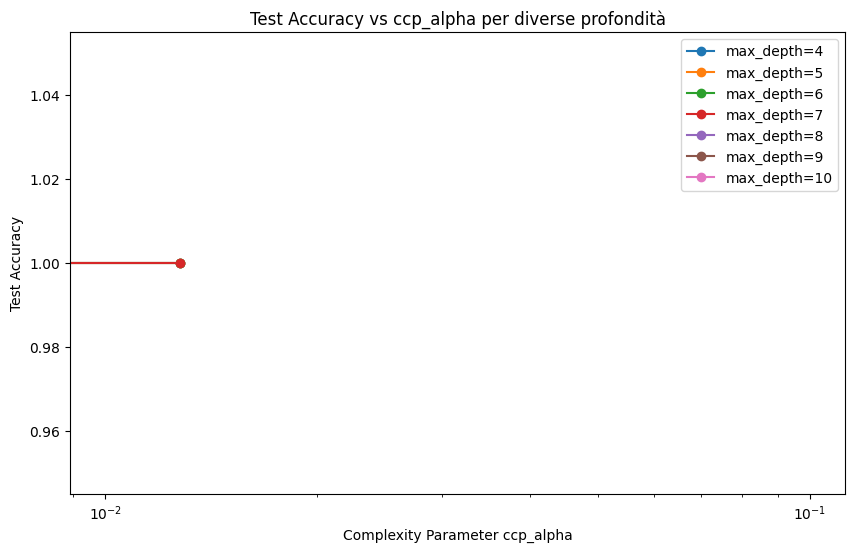

In [28]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["test_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [29]:
best_result = max(results, key=lambda x: x["test_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])

Miglior max_depth: 4
Miglior ccp_alpha: 0.0
Train accuracy: 1.0
Test accuracy: 1.0


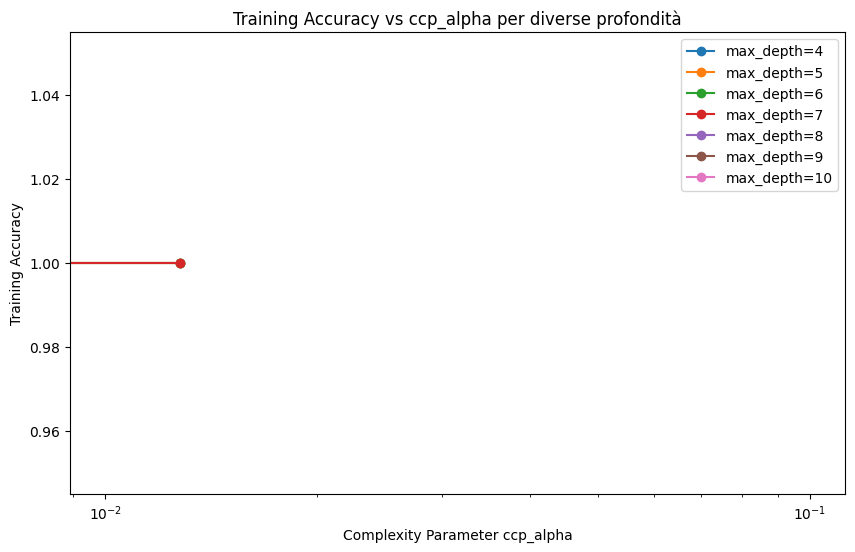

In [30]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [31]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 1.0
Accuracy test: 1.0


In [32]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[351   0]
 [  0   9]]

Accuracy: 1.0


In [33]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      1.00      1.00         9

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



### diamo un occhiata con la balancedPrecision

In [34]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      1.00      1.00         9

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360

Balanced accuracy: 1.0
[[351   0]
 [  0   9]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
            {0: 1, 1: 10}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [36]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 4.5},
    {0: 1, 1: 5},
    {0: 1, 1: 7},
    {0: 1, 1: 9},
    {0: 1, 1: 10}
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1"
)


Migliore configurazione trovata:
max_depth                             4
ccp_alpha                           0.0
class_weight               {0: 1, 1: 1}
weight_0                              1
weight_1                            1.0
train_accuracy                      1.0
test_accuracy                       1.0
train_balanced_accuracy             1.0
test_balanced_accuracy              1.0
precision_class_1                   1.0
recall_class_1                      1.0
f1_class_1                          1.0
macro_f1                            1.0
weighted_f1                         1.0
Name: 0, dtype: object

Confusion matrix:
[[351   0]
 [  0   9]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      1.00      1.00         9

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00   

In [37]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      1.00      1.00         9

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



### Facciamo un ensemble a majority

In [38]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [39]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, part_index in splitter.split(X_train, y_train):
        X_part = X_train.iloc[part_index]
        y_part = y_train.iloc[part_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "accuracy": test_accuracy,
                    "balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [40]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]


#clean_training_results[] = best_models, results_df, best_row, best_predictions

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)
clean_training_results = best_models, results_df, best_row, best_predictions

Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1}, 'weight_0': 1, 'weight_1': 1, 'accuracy': 0.9833333333333333, 'balanced_accuracy': 0.6666666666666666, 'precision_class_1': 1.0, 'recall_class_1': 0.3333333333333333, 'f1_class_1': 0.5, 'macro_f1': 0.7457627118644068, 'weighted_f1': 0.9792372881355932}

Confusion matrix:
[[351   0]
 [  6   3]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       351
           1       1.00      0.33      0.50         9

    accuracy                           0.98       360
   macro avg       0.99      0.67      0.75       360
weighted avg       0.98      0.98      0.98       360

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.5


In [41]:
results_df.sort_values(
    by="f1_class_1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,accuracy,balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
0,4,0.0,"{0: 1, 1: 1}",1,1.0,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
1,4,0.0,"{0: 1, 1: 1.5}",1,1.5,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
30,6,0.0,"{0: 1, 1: 2}",1,2.0,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
31,6,0.0,"{0: 1, 1: 2.5}",1,2.5,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
32,6,0.0,"{0: 1, 1: 3}",1,3.0,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
33,6,0.0,"{0: 1, 1: 4}",1,4.0,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
20,5,0.0,"{0: 1, 1: 5}",1,5.0,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
19,5,0.0,"{0: 1, 1: 4}",1,4.0,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
18,5,0.0,"{0: 1, 1: 3}",1,3.0,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237
17,5,0.0,"{0: 1, 1: 2.5}",1,2.5,0.983333,0.666667,1.0,0.333333,0.5,0.745763,0.979237


In [42]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       351
           1       1.00      0.33      0.50         9

    accuracy                           0.98       360
   macro avg       0.99      0.67      0.75       360
weighted avg       0.98      0.98      0.98       360



### proviamo  a fare undersampling del dataframe

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split


def train_test_split_with_undersampling(
    df,
    target_col,
    test_size=0.3,
    random_state=42,
    stratify=False
):
    """
    Divide il DataFrame in train/test e applica undersampling solo al training set.

    Parametri:
    - df: DataFrame completo
    - target_col: nome della colonna target, esempio "depression_label"
    - test_size: percentuale del test set
    - random_state: seed per riproducibilità
    - stratify: se True, mantiene proporzioni simili delle classi nello split

    Ritorna:
    - X_train_under
    - X_test
    - y_train_under
    - y_test
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    if stratify:
        stratify_values = y
    else:
        stratify_values = None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_values
    )

    train_df = X_train.copy()
    train_df[target_col] = y_train

    class_counts = train_df[target_col].value_counts()
    min_class_count = class_counts.min()

    undersampled_parts = []

    for class_value in class_counts.index:
        class_df = train_df[train_df[target_col] == class_value]

        class_df_under = class_df.sample(
            n=min_class_count,
            random_state=random_state
        )

        undersampled_parts.append(class_df_under)

    train_df_under = pd.concat(undersampled_parts)

    train_df_under = train_df_under.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X_train_under = train_df_under.drop(columns=[target_col])
    y_train_under = train_df_under[target_col]

    return X_train_under, X_test, y_train_under, y_test

In [44]:
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df=df_encoded,
    target_col="depression_label",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [45]:
y_train.value_counts()

depression_label
1    22
0    22
Name: count, dtype: int64

In [46]:
X_test.count()

age                         360
gender                      360
daily_social_media_hours    360
platform_usage              360
sleep_hours                 360
screen_time_before_sleep    360
academic_performance        360
physical_activity           360
social_interaction_level    360
stress_level                360
anxiety_level               360
addiction_level             360
dtype: int64

In [47]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1}, 'weight_0': 1, 'weight_1': 1, 'accuracy': 0.7388888888888889, 'balanced_accuracy': 0.8660968660968661, 'precision_class_1': 0.08737864077669903, 'recall_class_1': 1.0, 'f1_class_1': 0.16071428571428573, 'macro_f1': 0.5030545112781956, 'weighted_f1': 0.8282777255639098}

Confusion matrix:
[[257  94]
 [  0   9]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       351
           1       0.09      1.00      0.16         9

    accuracy                           0.74       360
   macro avg       0.54      0.87      0.50       360
weighted avg       0.98      0.74      0.83       360

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.16071428571428573


In [48]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.73      0.85       351
           1       0.09      1.00      0.16         9

    accuracy                           0.74       360
   macro avg       0.54      0.87      0.50       360
weighted avg       0.98      0.74      0.83       360



### Usiamo le random forests

In [49]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try,
    depths_to_try,
    weights_to_try,
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_model = None
    best_score = -1
    best_row = None
    best_predictions = None

    for n_estimators in n_estimators_to_try:
        for max_depth in depths_to_try:
            for weights in weights_to_try:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    class_weight=weights,
                    random_state=random_state,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                y_pred_train = rf.predict(X_train)
                y_pred_test = rf.predict(X_test)

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "class_weight": weights,
                    "weight_0": weights[0] if isinstance(weights, dict) else None,
                    "weight_1": weights[1] if isinstance(weights, dict) else None,

                    "train_accuracy": accuracy_score(y_train, y_pred_train),
                    "test_accuracy": accuracy_score(y_test, y_pred_test),
                    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),

                    "precision_class_1": precision_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "recall_class_1": recall_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "f1_class_1": f1_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        y_pred_test,
                        average="macro",
                        zero_division=0
                    )
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_model = rf
                    best_row = row
                    best_predictions = y_pred_test

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    return best_model, results_df, best_row, best_predictions

In [50]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

In [51]:
# best_rf.fit(X_train, y_train)

# y_pred_test = best_rf.predict(X_test)
# print(classification_report(y_test, y_pred_test, zero_division=0))

In [52]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

### Sporchiamo Il Dataset

In [53]:
# funzione per sporcare variabili categoriche
import numpy as np

import numpy as np







def corrupt_rows_cat(X_train, col, frac=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    # Generatore casuale riproducibile
    rng = np.random.default_rng(random_state)

    # Recupero i valori univoci della colonna
    unique_values = X_train_corrupt[col].unique()

    # Se esiste un solo valore, non posso sostituirlo con qualcosa di diverso
    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return X_train_corrupt

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    # Scelgo righe casuali senza ripetizione
    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Per ogni riga scelta, sostituisco il valore con un altro diverso
    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        pool_of_new_values = unique_values[unique_values != current_value]

        X_train_corrupt.at[idx, col] = rng.choice(pool_of_new_values)

    return X_train_corrupt


def corrupt_rows_cont(X_train, col, frac=0.1, noise_level=0.5, random_state=None):
    X_train_corrupt = X_train.copy()

    rng = np.random.default_rng(random_state)

    # Converto la colonna in float, così posso inserirci valori decimali
    X_train_corrupt[col] = X_train_corrupt[col].astype(float)

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    # Scelgo gli indici delle righe da corrompere
    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Deviazione standard della colonna
    std_col = X_train_corrupt[col].std()

    if std_col == 0:
        print(f"Attenzione: la colonna '{col}' ha deviazione standard 0. Nessuna modifica applicata.")
        return X_train_corrupt

    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        noise = rng.normal(
            loc=0,
            scale=noise_level * std_col
        )

        X_train_corrupt.at[idx, col] = current_value + noise

    return X_train_corrupt



### mostro le variabili dalla più importante alla meno importante

In [54]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# separo feature e target
X = df_encoded.drop(columns=["depression_label"])
y = df_encoded["depression_label"]

# scrivi qui le colonne categoriche
categoriche = ["gender"]

# True per le categoriche, False per le continue
discrete_mask = []

for col in X.columns:
    if col in categoriche:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

# calcolo mutual information
mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

# creo tabella ordinata
importanza_variabili = pd.DataFrame({
    "variabile": X.columns,
    "importanza": mi
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza",
    ascending=False
)

print(importanza_variabili)

                   variabile  importanza
10             anxiety_level    0.029477
9               stress_level    0.026163
2   daily_social_media_hours    0.020099
4                sleep_hours    0.019672
11           addiction_level    0.000366
1                     gender    0.000197
6       academic_performance    0.000072
0                        age    0.000000
3             platform_usage    0.000000
5   screen_time_before_sleep    0.000000
7          physical_activity    0.000000
8   social_interaction_level    0.000000


In [55]:
feature_ordinate = importanza_variabili["variabile"].tolist()
n = len(feature_ordinate)
meta = n // 2

if n % 2 == 0:
    migliori = feature_ordinate[:meta]
    peggiori = feature_ordinate[meta:]
else:
    # la feature centrale appartiene a entrambe le liste
    migliori = feature_ordinate[:meta + 1]
    peggiori = feature_ordinate[meta:]

print("Migliori:", migliori)
print("Peggiori:", peggiori)

Migliori: ['anxiety_level', 'stress_level', 'daily_social_media_hours', 'sleep_hours', 'addiction_level', 'gender']
Peggiori: ['academic_performance', 'age', 'platform_usage', 'screen_time_before_sleep', 'physical_activity', 'social_interaction_level']


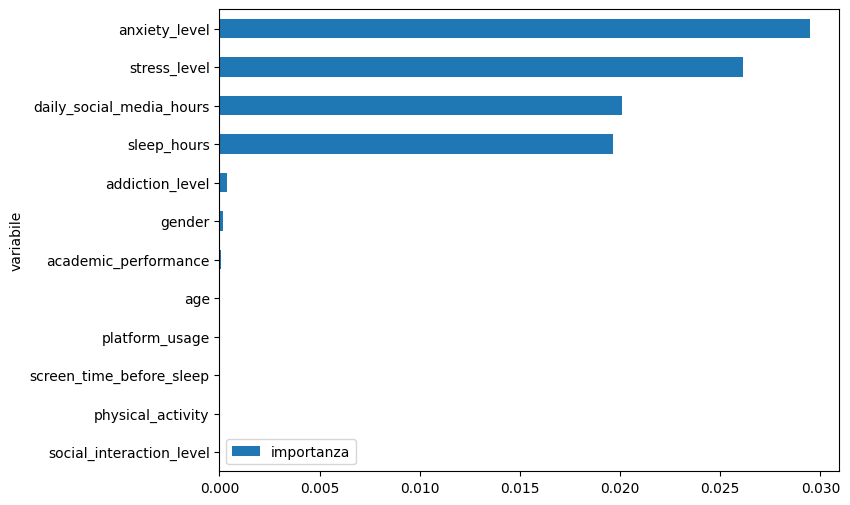

In [56]:
import matplotlib.pyplot as plt

importanza_variabili.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.show()

### Proviamo a sporcare la feature SGPT in maniera progressiva mentre lo addestriamo e vediamo di quanto cala la performance del modello

In [57]:
df_encoded.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


In [58]:
## AG ratio è continua, voglio quindi usare la funzione che sporca colonno continue
# una volta sporcata faccio partire un giro di training su ensemble
# dopo di che faccio una valutazione del modello e la confronto con il modello addestrato sul dataset non sporco

In [59]:
non_corrupted_data = [X_train, X_test, y_train, y_test]

In [60]:
#occhio, sto sovrascrivendo gli x_train e y_train puliti,non è un errore ma bisogna ricordarselo
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df_encoded,
    target_col="depression_label",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [61]:
# df_corrotto = corrupt_rows_cont(
#     df_encoded,
#     col="Sgpt",
#     frac=0.2,
#     noise_level=0.5,
#     random_state=42
# )

In [62]:
noise_training_results = [] #best_models, results_df, best_row, best_predictions 

noise_training_results= search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1}, 'weight_0': 1, 'weight_1': 1, 'accuracy': 0.7388888888888889, 'balanced_accuracy': 0.8660968660968661, 'precision_class_1': 0.08737864077669903, 'recall_class_1': 1.0, 'f1_class_1': 0.16071428571428573, 'macro_f1': 0.5030545112781956, 'weighted_f1': 0.8282777255639098}

Confusion matrix:
[[257  94]
 [  0   9]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       351
           1       0.09      1.00      0.16         9

    accuracy                           0.74       360
   macro avg       0.54      0.87      0.50       360
weighted avg       0.98      0.74      0.83       360

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.16071428571428573


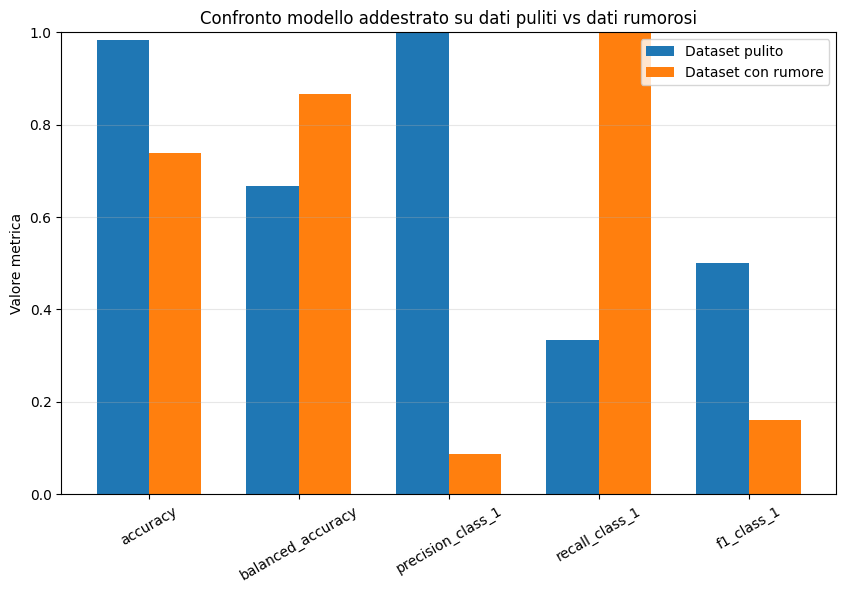

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Risultati modello pulito
clean_best_models, clean_results_df, clean_best_row, clean_best_predictions = clean_training_results

# Risultati modello con rumore
noise_best_models, noise_results_df, noise_best_row, noise_best_predictions = noise_training_results


# Funzione per trasformare best_row sempre in dizionario
def best_row_to_dict(best_row):
    if isinstance(best_row, pd.DataFrame):
        return best_row.iloc[0].to_dict()
    
    if isinstance(best_row, pd.Series):
        return best_row.to_dict()
    
    if isinstance(best_row, dict):
        return best_row
    
    raise TypeError("best_row deve essere un dict, una Series o un DataFrame")


clean_best_row = best_row_to_dict(clean_best_row)
noise_best_row = best_row_to_dict(noise_best_row)


# Metriche che voglio confrontare
possible_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1"
]

# Tengo solo le metriche presenti in entrambi
metrics = []

for metric in possible_metrics:
    if metric in clean_best_row.keys() and metric in noise_best_row.keys():
        metrics.append(metric)


# Valori delle metriche
clean_values = []

for metric in metrics:
    clean_values.append(clean_best_row[metric])


noise_values = []

for metric in metrics:
    noise_values.append(noise_best_row[metric])


# Grafico
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, clean_values, width, label="Dataset pulito")
plt.bar(x + width/2, noise_values, width, label="Dataset con rumore")

plt.xticks(x, metrics, rotation=30)
plt.ylabel("Valore metrica")
plt.title("Confronto modello addestrato su dati puliti vs dati rumorosi")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [64]:
df_encoded.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


In [65]:

# X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
#     df=df_encoded,
#     target_col="Gender",
#     test_size=0.7,
#     random_state=42,
#     stratify=False
# )



In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def test_noise_progressivo(
    df,
    target_col,
    cols_to_corrupt,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non devi sporcare la colonna target.")

    # ✔ SPLIT UNICO (FIX come NN e SVM)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    # ✔ identificazione tipo colonne
    tipo_colonne = {}

    for col in cols_to_corrupt:

        is_categorical = (
            col in categorical_cols or
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool" or
            (
                pd.api.types.is_integer_dtype(df[col]) and
                df[col].nunique() <= max_unique_for_cat
            )
        )

        tipo_colonne[col] = is_categorical

    print("Colonne da corrompere:")
    for col, is_cat in tipo_colonne.items():
        print(f" - {col}: {'categorica' if is_cat else 'continua'}")

    # ✔ rumore progressivo (include 0%)
    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        # reset train base
        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # ✔ applicazione rumore su più colonne
        for col in cols_to_corrupt:

            if tipo_colonne[col]:

                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=random_state
                )

            else:

                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=random_state
                )

        # ✔ training modello (ensemble tree search invariato)
        training_results = search_best_ensemble_tree(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            ccp_alphas=ccp_alphas,
            weights_to_try=weights_to_try,
            depths=depths,
            scoring_metric=scoring_metric,
            random_state=random_state
        )

        best_models, results_df, best_row, best_predictions = training_results

        accuracy = accuracy_score(y_test, best_predictions)

        # ✔ normalizzazione best_row
        if isinstance(best_row, pd.DataFrame):
            best_row_dict = best_row.iloc[0].to_dict()
        elif isinstance(best_row, pd.Series):
            best_row_dict = best_row.to_dict()
        elif isinstance(best_row, dict):
            best_row_dict = best_row.copy()
        else:
            raise TypeError("best_row formato non valido")

        best_row_dict.update({
            "accuracy": accuracy,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "tipo_colonne": str(tipo_colonne),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_finali.append(best_row_dict)

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "best_models": best_models,
            "results_df": results_df,
            "best_row": best_row,
            "best_predictions": best_predictions,
            "accuracy": accuracy
        }

    # ✔ dataframe finale
    risultati_df = pd.DataFrame(risultati_finali)

    # ✔ metriche disponibili
    metriche_possibili = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    metriche_presenti = [
        m for m in metriche_possibili if m in risultati_df.columns
    ]

    print(risultati_df)

    # ✔ grafico
    plt.figure(figsize=(10, 6))

    for m in metriche_presenti:

        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale di rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza ensemble alberi su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.xticks(risultati_df["percentuale_rumore"])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return risultati_df, risultati_completi

In [67]:
df_encoded.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


Colonne da corrompere:
 - academic_performance: continua
 - age: categorica
 - platform_usage: categorica
 - screen_time_before_sleep: continua
 - physical_activity: continua
 - social_interaction_level: categorica

Rumore: 0%
Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.0), 'class_weight': 'balanced', 'weight_0': 'b', 'weight_1': 'a', 'accuracy': 0.9944444444444445, 'balanced_accuracy': 0.8888888888888888, 'precision_class_1': 1.0, 'recall_class_1': 0.7777777777777778, 'f1_class_1': 0.875, 'macro_f1': 0.9360795454545454, 'weighted_f1': 0.9941051136363637}

Confusion matrix:
[[351   0]
 [  2   7]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       351
           1       1.00      0.78      0.88         9

    accuracy                           0.99       360
   macro avg       1.00      0.89      0.94       360
weighted avg       0.99      0.99      0.99       360

Metrica usata

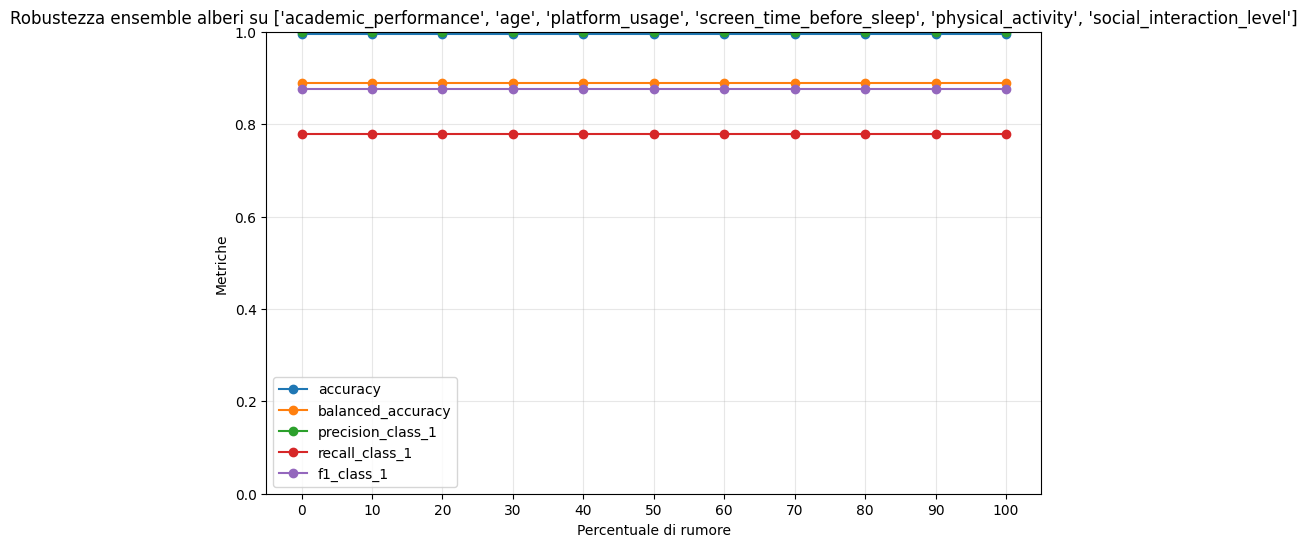

In [68]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="depression_label",
    cols_to_corrupt=peggiori,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False
)


Colonne da corrompere:
 - anxiety_level: categorica
 - stress_level: categorica
 - daily_social_media_hours: continua
 - sleep_hours: continua
 - addiction_level: categorica
 - gender: categorica

Rumore: 0%
Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.0), 'class_weight': 'balanced', 'weight_0': 'b', 'weight_1': 'a', 'accuracy': 0.9944444444444445, 'balanced_accuracy': 0.8888888888888888, 'precision_class_1': 1.0, 'recall_class_1': 0.7777777777777778, 'f1_class_1': 0.875, 'macro_f1': 0.9360795454545454, 'weighted_f1': 0.9941051136363637}

Confusion matrix:
[[351   0]
 [  2   7]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       351
           1       1.00      0.78      0.88         9

    accuracy                           0.99       360
   macro avg       1.00      0.89      0.94       360
weighted avg       0.99      0.99      0.99       360

Metrica usata per scegliere: f1_

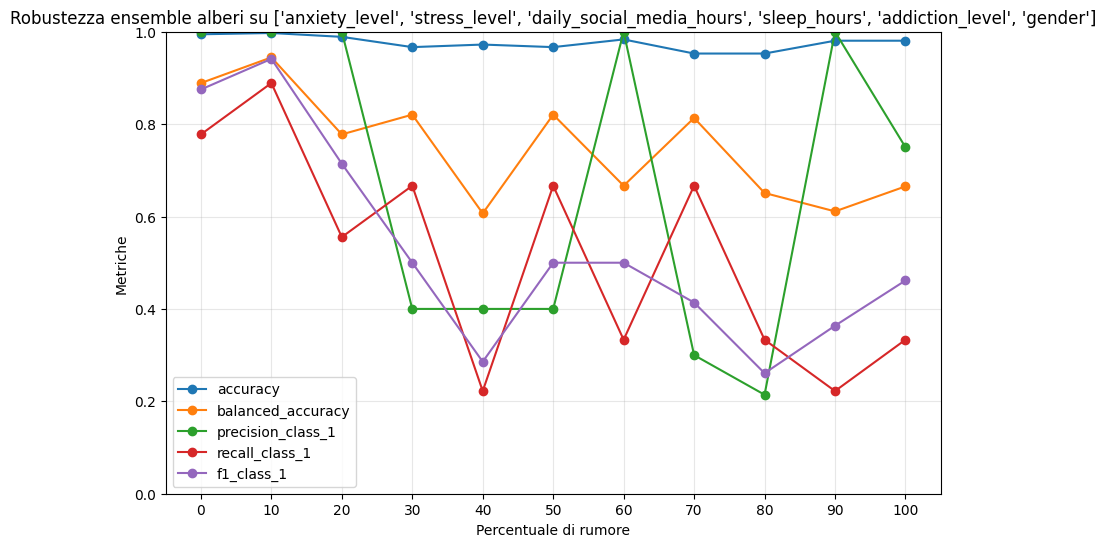

In [69]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="depression_label",
    cols_to_corrupt=migliori,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False
)

Inizio rete neurale


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf


In [71]:
y = df_encoded["depression_label"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [72]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
import numpy as np
from sklearn.metrics import confusion_matrix

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_pred = model.predict(X_test)

# conversione probabilità in classi
y_pred = (y_pred > 0.5).astype(int)



cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Confusion matrix:
 [[351   0]
 [  9   0]]

Accuracy: 0.975


In [74]:
def build_model_NN(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return model


def ensemble_predict_NN(models, X):
    preds = []

    for m in models:
        preds.append(m.predict(X, verbose=0))

    mean_pred = np.mean(preds, axis=0)
    return (mean_pred > 0.5).astype(int).flatten()



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def test_noise_progressivo_NN(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non puoi sporcare il target")

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    print("Colonne da corrompere:")
    for k, v in tipo_colonne.items():
        print(f" - {k}: {'categorica' if v else 'continua'}")

    #  SPLIT UNICO
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # ✔ CORRUZIONE
        for col in cols_to_corrupt:

            if tipo_colonne[col]:
                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=random_state
                )
            else:
                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=random_state
                )

        models = []

        #  ENSEMBLE CON BOOTSTRAP
        for i in range(3):

            tf.random.set_seed(random_state + i)

            idx = np.random.choice(len(X_train), len(X_train), replace=True)

            X_boot = X_train.iloc[idx]
            y_boot = y_train.iloc[idx]

            model = tf.keras.Sequential([
                tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
                tf.keras.layers.Dense(16, activation="relu"),
                tf.keras.layers.Dense(1, activation="sigmoid")
            ])

            model.compile(
                optimizer="adam",
                loss="binary_crossentropy"
            )

            model.fit(
                X_boot,
                y_boot,
                epochs=30,
                batch_size=32,
                verbose=0
            )

            models.append(model)

        #  PREDIZIONE ENSEMBLE
        preds = []

        for m in models:
            preds.append(m.predict(X_test, verbose=0))

        mean_pred = np.mean(preds, axis=0)
        y_pred = (mean_pred > 0.5).astype(int).flatten()

        #  METRICHE
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        risultati_finali.append({
            "accuracy": accuracy,
            "f1_class_1": f1,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "balanced_accuracy": balanced_acc,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "models": models,
            "y_pred": y_pred
        }

    risultati_df = pd.DataFrame(risultati_finali)

    #  GRAFICO
    metriche = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza NN ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)

    return risultati_df, risultati_completi

Colonne da corrompere:
 - academic_performance: continua
 - age: categorica
 - platform_usage: categorica
 - screen_time_before_sleep: continua
 - physical_activity: continua
 - social_interaction_level: categorica

Rumore: 0%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 10%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 20%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 30%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 40%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 50%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 60%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 70%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 80%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 90%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 100%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula

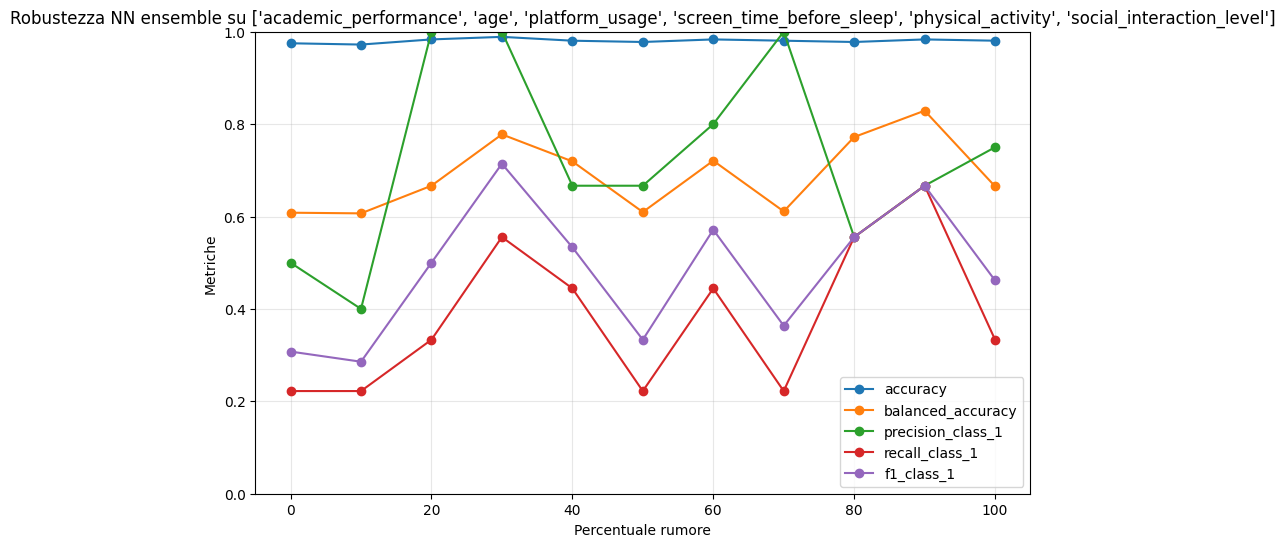

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.975000    0.307692           0.500000        0.222222   
1   0.972222    0.285714           0.400000        0.222222   
2   0.983333    0.500000           1.000000        0.333333   
3   0.988889    0.714286           1.000000        0.555556   
4   0.980556    0.533333           0.666667        0.444444   
5   0.977778    0.333333           0.666667        0.222222   
6   0.983333    0.571429           0.800000        0.444444   
7   0.980556    0.363636           1.000000        0.222222   
8   0.977778    0.555556           0.555556        0.555556   
9   0.983333    0.666667           0.666667        0.666667   
10  0.980556    0.461538           0.750000        0.333333   

    balanced_accuracy                                   colonne_sporcate  \
0            0.608262  academic_performance,age,platform_usage,screen...   
1            0.606838  academic_performance,age,platform_usage,screen...   
2            0.

In [75]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="depression_label",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    stratify=False,
)

Colonne da corrompere:
 - anxiety_level: categorica
 - stress_level: categorica
 - daily_social_media_hours: continua
 - sleep_hours: continua
 - addiction_level: categorica
 - gender: categorica

Rumore: 0%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 10%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 20%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 30%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 40%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 50%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 60%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Rumore: 70%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 80%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Rumore: 90%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regula


Rumore: 100%


/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/a_/Library/Python/3.10/lib/python/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

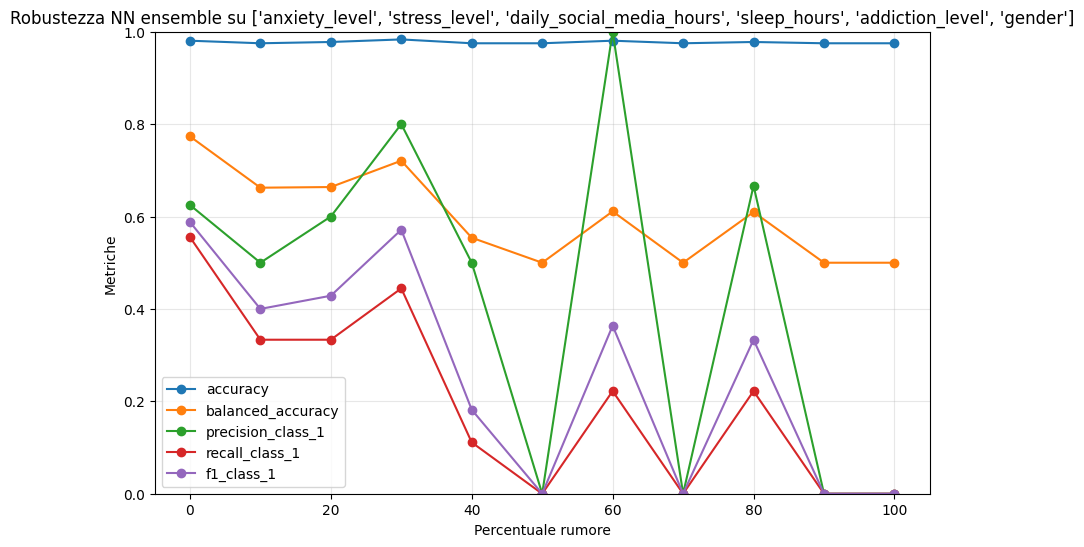

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.980556    0.588235           0.625000        0.555556   
1   0.975000    0.400000           0.500000        0.333333   
2   0.977778    0.428571           0.600000        0.333333   
3   0.983333    0.571429           0.800000        0.444444   
4   0.975000    0.181818           0.500000        0.111111   
5   0.975000    0.000000           0.000000        0.000000   
6   0.980556    0.363636           1.000000        0.222222   
7   0.975000    0.000000           0.000000        0.000000   
8   0.977778    0.333333           0.666667        0.222222   
9   0.975000    0.000000           0.000000        0.000000   
10  0.975000    0.000000           0.000000        0.000000   

    balanced_accuracy                                   colonne_sporcate  \
0            0.773504  anxiety_level,stress_level,daily_social_media_...   
1            0.662393  anxiety_level,stress_level,daily_social_media_...   
2            0.

In [76]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="depression_label",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    stratify=False,
)

Inizio svg

In [77]:
y = df_encoded["depression_label"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [78]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Creazione del modello SVM
model = SVC(
    kernel="rbf",        
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

# Addestramento
model.fit(X_train, y_train)

# Predizioni
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

Confusion matrix:
 [[348   3]
 [  3   6]]

Accuracy: 0.9833333333333333


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_SVM():
    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )
    return model


def ensemble_predict_SVM(models, X):

    preds = []

    for m in models:
        preds.append(m.predict(X))

    preds = np.array(preds)

    # Majority voting
    y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

    return y_pred




def test_noise_progressivo_SVM(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non puoi sporcare il target")

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    print("Colonne da corrompere:")
    for k, v in tipo_colonne.items():
        print(f" - {k}: {'categorica' if v else 'continua'}")

    # SPLIT UNA SOLA VOLTA (FIX come NN)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # CORRUZIONE
        for col in cols_to_corrupt:

            if tipo_colonne[col]:
                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=random_state
                )
            else:
                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=random_state
                )

        models = []

        # ENSEMBLE CON BOOTSTRAP (FIX come NN)
        for i in range(3):

            idx = np.random.choice(len(X_train), len(X_train), replace=True)

            X_boot = X_train.iloc[idx]
            y_boot = y_train.iloc[idx]

            model = SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced"
            )

            model.fit(X_boot, y_boot)

            models.append(model)

        # PREDIZIONE ENSEMBLE (majority vote coerente)
        preds = []

        for m in models:
            preds.append(m.predict(X_test))

        preds = np.array(preds)

        y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

        # METRICHE
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        risultati_finali.append({
            "accuracy": accuracy,
            "f1_class_1": f1,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "balanced_accuracy": balanced_acc,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "models": models,
            "y_pred": y_pred
        }

    risultati_df = pd.DataFrame(risultati_finali)

    # GRAFICO IDENTICO NN
    metriche = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza SVM ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)

    return risultati_df, risultati_completi

Colonne da corrompere:
 - academic_performance: continua
 - age: categorica
 - platform_usage: categorica
 - screen_time_before_sleep: continua
 - physical_activity: continua
 - social_interaction_level: categorica

Rumore: 0%

Rumore: 10%

Rumore: 20%

Rumore: 30%

Rumore: 40%

Rumore: 50%

Rumore: 60%

Rumore: 70%

Rumore: 80%

Rumore: 90%

Rumore: 100%


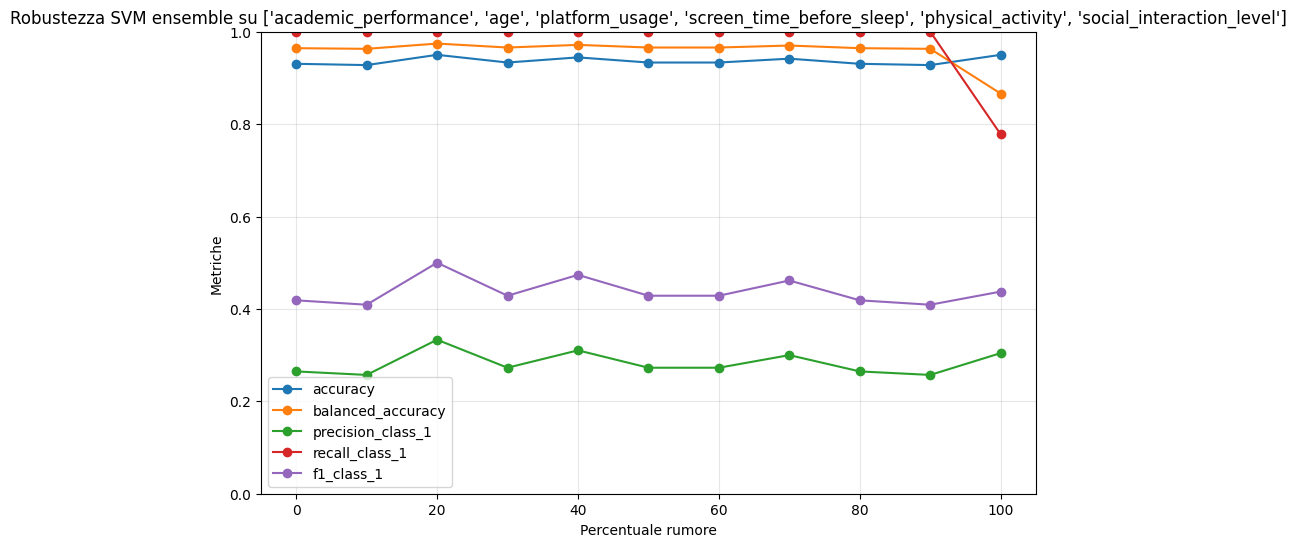

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.930556    0.418605           0.264706        1.000000   
1   0.927778    0.409091           0.257143        1.000000   
2   0.950000    0.500000           0.333333        1.000000   
3   0.933333    0.428571           0.272727        1.000000   
4   0.944444    0.473684           0.310345        1.000000   
5   0.933333    0.428571           0.272727        1.000000   
6   0.933333    0.428571           0.272727        1.000000   
7   0.941667    0.461538           0.300000        1.000000   
8   0.930556    0.418605           0.264706        1.000000   
9   0.927778    0.409091           0.257143        1.000000   
10  0.950000    0.437500           0.304348        0.777778   

    balanced_accuracy                                   colonne_sporcate  \
0            0.964387  academic_performance,age,platform_usage,screen...   
1            0.962963  academic_performance,age,platform_usage,screen...   
2            0.

In [81]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="depression_label",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    stratify=False,
)

Colonne da corrompere:
 - anxiety_level: categorica
 - stress_level: categorica
 - daily_social_media_hours: continua
 - sleep_hours: continua
 - addiction_level: categorica
 - gender: categorica

Rumore: 0%

Rumore: 10%

Rumore: 20%

Rumore: 30%

Rumore: 40%

Rumore: 50%

Rumore: 60%

Rumore: 70%

Rumore: 80%

Rumore: 90%

Rumore: 100%


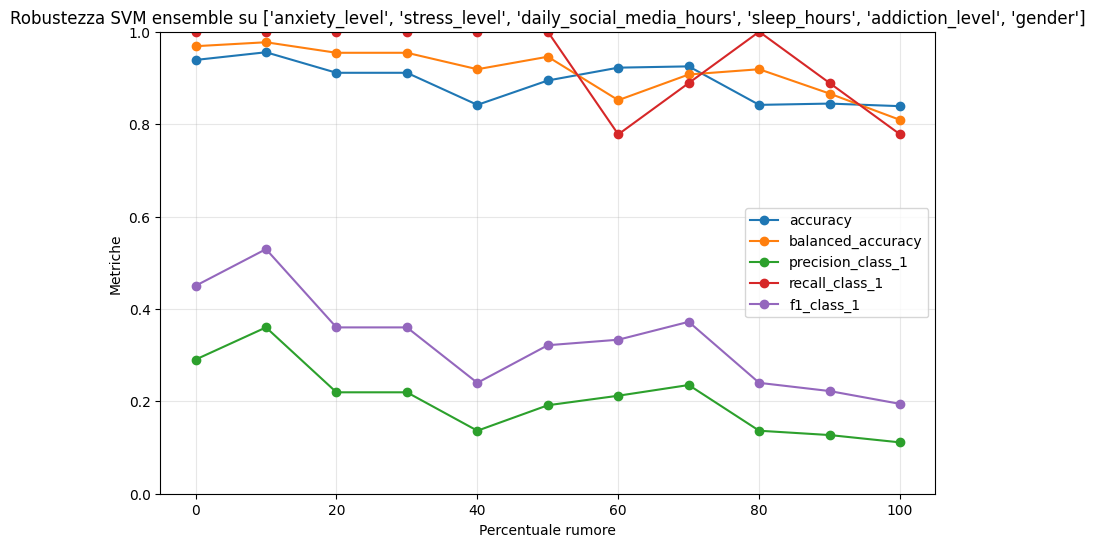

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.938889    0.450000           0.290323        1.000000   
1   0.955556    0.529412           0.360000        1.000000   
2   0.911111    0.360000           0.219512        1.000000   
3   0.911111    0.360000           0.219512        1.000000   
4   0.841667    0.240000           0.136364        1.000000   
5   0.894444    0.321429           0.191489        1.000000   
6   0.922222    0.333333           0.212121        0.777778   
7   0.925000    0.372093           0.235294        0.888889   
8   0.841667    0.240000           0.136364        1.000000   
9   0.844444    0.222222           0.126984        0.888889   
10  0.838889    0.194444           0.111111        0.777778   

    balanced_accuracy                                   colonne_sporcate  \
0            0.968661  anxiety_level,stress_level,daily_social_media_...   
1            0.977208  anxiety_level,stress_level,daily_social_media_...   
2            0.

In [82]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="depression_label",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    stratify=False,
)